In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on Device: {device}")

Working on Device: cuda


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
# Validation & Test Normalization
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
TRAIN_DIR = os.path.join(path, 'Training')
TEST_DIR = os.path.join(path, 'Testing')

In [13]:
# Load Datasets
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transforms)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f"Classes found ({num_classes}): {class_names}")

Classes found (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


In [14]:
# Training Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [16]:
# Split Training into 85% Train & 15% Validation
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

val_dataset.dataset.transform = eval_transforms

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
# ---------------------------------------------------------
# 1. Model Setup (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Replace final linear layer for 4 classes
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 50.4MB/s]


In [20]:
# ---------------------------------------------------------
# 2. Training and Validation Loop
# ---------------------------------------------------------
EPOCHS = 8
best_val_acc = 0.0
MODEL_PATH = "best_brain_tumor_model.pth"

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_loss, train_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = train_corrects.double() / len(train_dataset)

    # Validation Phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Save Best Model Checkpoint
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"   ---> Best model saved with Validation Accuracy: {best_val_acc:.4f}")

Epoch 1/8 | Train Loss: 0.0392 | Train Acc: 0.9882 | Val Loss: 0.0509 | Val Acc: 0.9845
   ---> Best model saved with Validation Accuracy: 0.9845
Epoch 2/8 | Train Loss: 0.0307 | Train Acc: 0.9903 | Val Loss: 0.0369 | Val Acc: 0.9869
   ---> Best model saved with Validation Accuracy: 0.9869
Epoch 3/8 | Train Loss: 0.0180 | Train Acc: 0.9956 | Val Loss: 0.0717 | Val Acc: 0.9810
Epoch 4/8 | Train Loss: 0.0183 | Train Acc: 0.9954 | Val Loss: 0.0517 | Val Acc: 0.9869
Epoch 5/8 | Train Loss: 0.0190 | Train Acc: 0.9943 | Val Loss: 0.0385 | Val Acc: 0.9857
Epoch 6/8 | Train Loss: 0.0134 | Train Acc: 0.9952 | Val Loss: 0.0418 | Val Acc: 0.9881
   ---> Best model saved with Validation Accuracy: 0.9881
Epoch 7/8 | Train Loss: 0.0083 | Train Acc: 0.9979 | Val Loss: 0.0466 | Val Acc: 0.9905
   ---> Best model saved with Validation Accuracy: 0.9905
Epoch 8/8 | Train Loss: 0.0140 | Train Acc: 0.9958 | Val Loss: 0.0514 | Val Acc: 0.9857



--- Final Evaluation on Unseen Test Dataset ---

Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.81      0.90       400
  meningioma       0.88      1.00      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



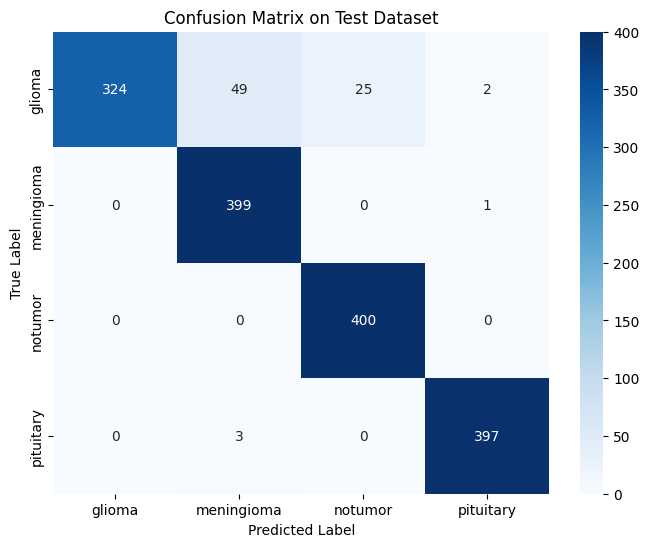

In [21]:
# ---------------------------------------------------------
# 4. Final Evaluation on Unseen Test Set & Plots
# ---------------------------------------------------------
print("\n--- Final Evaluation on Unseen Test Dataset ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Precision, Recall, F1-Score Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()